# Prévision naïve

Objectif : peut-on prévoir la consommation moyenne de demain ?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
eco2mix=pd.read_csv("../data/eco2mix_2023_2024.csv", sep=";")
eco2mix=eco2mix.dropna(subset=['consommation'])
eco2mix['date_heure']=pd.to_datetime(eco2mix['date_heure'])
meteo=pd.read_csv('../data/meteo_2023_2024.csv', sep=',')
meteo['date_heure'] = pd.to_datetime(meteo['date_heure']).dt.tz_localize("UTC")
eco2mix["date"] = eco2mix["date_heure"].dt.floor("D")
meteo["date"] = meteo["date_heure"].dt.floor("D")
conso_jour = eco2mix.groupby('date')['consommation'].mean().reset_index()
temp_jour = meteo.groupby('date')['temp_france'].mean().reset_index()
df_jour=pd.merge(conso_jour,temp_jour,on='date')

In [3]:
df_jour.count()

date            731
consommation    731
temp_france     731
dtype: int64

In [4]:
df_jour.head()

,date,consommation,temp_france
0,2023-01-01 00:00:00+00:00,43010.500000,13.369792
1,2023-01-02 00:00:00+00:00,50014.312500,11.054688
2,2023-01-03 00:00:00+00:00,56098.625000,8.559375
3,2023-01-04 00:00:00+00:00,56889.291667,9.498958
4,2023-01-05 00:00:00+00:00,55379.729167,10.456250


In [5]:
df_jour["conso_veille"] = df_jour["consommation"].shift(1)

In [6]:
df_jour.head()

,date,consommation,temp_france,conso_veille
0,2023-01-01 00:00:00+00:00,43010.500000,13.369792,NaN
1,2023-01-02 00:00:00+00:00,50014.312500,11.054688,43010.500000
2,2023-01-03 00:00:00+00:00,56098.625000,8.559375,50014.312500
3,2023-01-04 00:00:00+00:00,56889.291667,9.498958,56098.625000
4,2023-01-05 00:00:00+00:00,55379.729167,10.456250,56889.291667


In [7]:
df_jour.tail()

,date,consommation,temp_france,conso_veille
726,2024-12-27 00:00:00+00:00,62610.645833,3.123958,57632.687500
727,2024-12-28 00:00:00+00:00,63067.791667,2.100000,62610.645833
728,2024-12-29 00:00:00+00:00,61624.875000,2.407812,63067.791667
729,2024-12-30 00:00:00+00:00,65532.958333,2.768229,61624.875000
730,2024-12-31 00:00:00+00:00,66013.020833,2.892708,65532.958333


In [8]:
df_2024 = df_jour[df_jour["date"].dt.year == 2024].copy()

In [9]:
df_2024.head()

,date,consommation,temp_france,conso_veille
365,2024-01-01 00:00:00+00:00,51536.062500,7.871354,51852.791667
366,2024-01-02 00:00:00+00:00,56737.312500,10.125000,51536.062500
367,2024-01-03 00:00:00+00:00,57533.729167,10.409375,56737.312500
368,2024-01-04 00:00:00+00:00,58085.229167,9.282813,57533.729167
369,2024-01-05 00:00:00+00:00,59455.000000,7.446354,58085.229167


In [10]:
len(df_2024)

366

En effet, 2024 est une année bisextile.

In [11]:
mae_naive = (df_2024["consommation"] - df_2024["conso_veille"]).abs().mean()
round(mae_naive)

2316

On constate alors que l'erreur moyenne de note prédiction naive est de 2316MW par jour, soit 5% de la consommation journalière moyenne.

In [12]:
df_2024['erreur_jour']=(df_2024["consommation"] - df_2024["conso_veille"]).abs()

In [13]:
df_2024['jour']=df_2024['date'].dt.dayofweek

In [14]:
df_2024['mois']=df_2024['date'].dt.month

<Axes: title={'center': 'Erreur naïve par mois'}, xlabel='mois'>

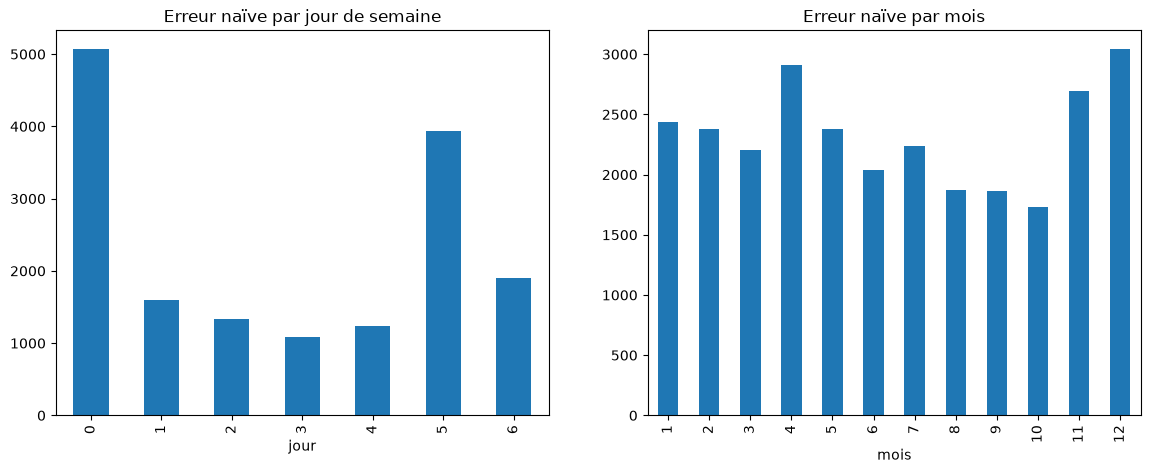

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
df_2024.groupby('jour')['erreur_jour'].mean().plot(kind='bar', ax=ax1, title='Erreur naïve par jour de semaine')
df_2024.groupby('mois')['erreur_jour'].mean().plot(kind='bar', ax=ax2, title='Erreur naïve par mois')

On voit clairement là où on se trompe le plus. Sur les jours de la semaine, on se trompe surtout pour le lundi et le samedi, 5000 MW et 4000 MW d'erreur respectivement, soit presque le double de notre erreur moyenne (2316 MW), on peut expliquer cela par le fait que ce soient les deux jours frontaliers entre jours de semaine et weekend, les deux tranches de la semaine qui varient le plus entre elles, et vu que la méthode naïve copie la veille, c'est exactement sur ces transitions qu'elle se plante.

Pour les mois, on se trompe surtout pour les mois d'avril, novembre et décembre, avec des erreurs autour des 3000 MW par jour pour ces 3 extremums, soit environ 30% de plus que la moyenne annuelle. En effet, ce sont des mois à météo instable où deux jours qui se suivent peuvent être très différents, et ce sont aussi des mois avec plusieurs jours fériés (Pâques, le 1er et le 11 novembre, Noël), des ruptures que la méthode naïve ne peut pas prévoir.